<a href="https://colab.research.google.com/github/faridsimba87-cpu/CDAV/blob/main/Lesson_4_Seaborn_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Seaborn Library Tutorial**

### **Prepare Environment**

In [ ]:
# Install seaborn package
!pip install seaborn

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Get the list the inbuilt datasets in Seaborn
print(len(sns.get_dataset_names()))
print("...........................")
sns.get_dataset_names()

22
...........................


['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
# Load datasets from the seaborn library
tips = sns.load_dataset('tips')
penguins = sns.load_dataset("penguins").dropna()
flights  = sns.load_dataset("flights")
fmri     = sns.load_dataset("fmri")

### **Axes Level Function API**

More granular control over individual plots

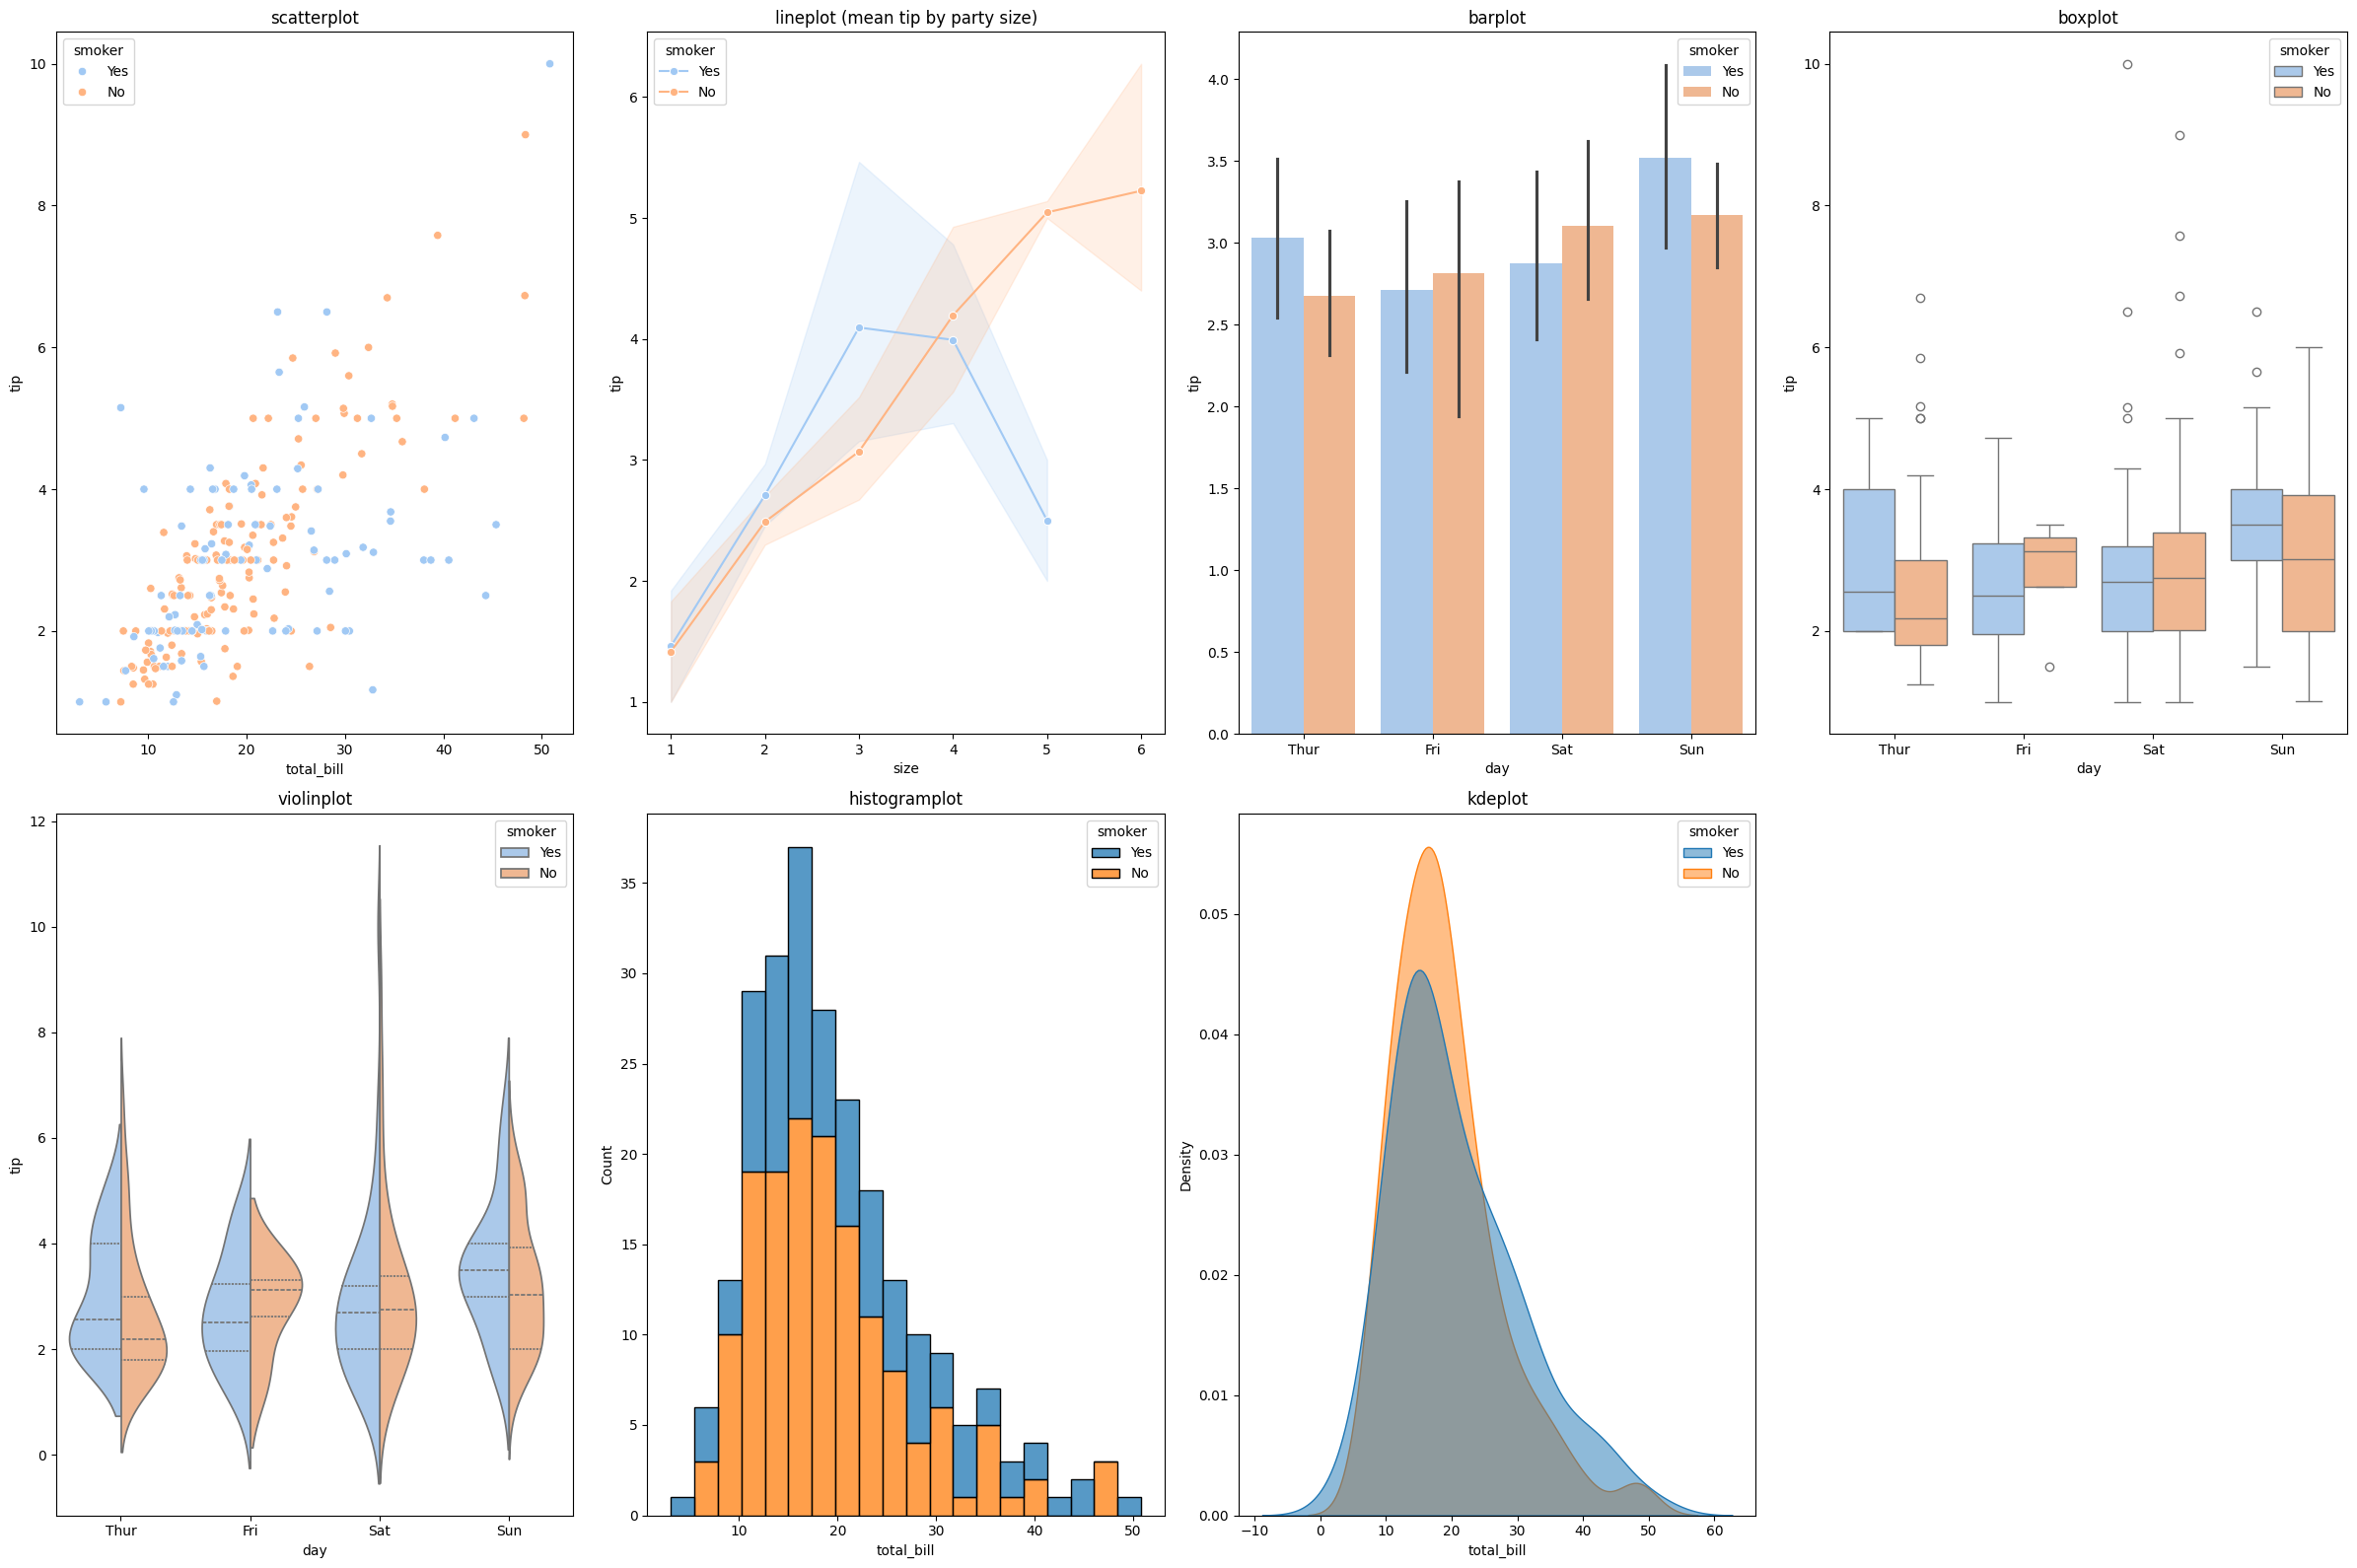

In [ ]:
# Using Matplotlib to set the size of the canvas
fig, axes = plt.subplots(2, 4, figsize=(24, 16))
ax = axes.flat

"""
Note on axes.flat
Gives you a 1-D view of a 2-D grid of axes, so you can reach each subplot by a single index instead of a row/column pair.
ax = axes.flat
ax[0]  ->  axes[0,0]
ax[1]  ->  axes[0,1]
ax[2]  ->  axes[1,0]
ax[3]  ->  axes[1,1]
"""

# scatterplot: relationship of numerical variables
sns.scatterplot(data=tips, x="total_bill", y="tip",
                hue="smoker", palette="pastel",
                ax=ax[0])
ax[0].set_title("scatterplot")

# lineplot — aggregated trend over discrete x
sns.lineplot(data=tips, x="size", y="tip",
             hue="smoker", marker="o",
             palette="pastel", ax=ax[1])
ax[1].set_title("lineplot (mean tip by party size)")

# barplot — category summaries (mean by default)
sns.barplot(data=tips, x="day", y="tip",
            hue="smoker", palette="pastel", ax=ax[2])
ax[2].set_title("barplot")

# boxplot — distribution across categories
sns.boxplot(data=tips, x="day", y="tip",
            hue="smoker", palette="pastel", ax=ax[3])
ax[3].set_title("boxplot")

# violinplot — smoothed distribution shape
sns.violinplot(data=tips, x="day", y="tip",
               hue="smoker", split=True,
               inner="quartile",
               palette="pastel", ax=ax[4])
ax[4].set_title("violinplot")

# histplot — histogram
sns.histplot(data=tips, x="total_bill",
             hue="smoker", bins=20, multiple="stack",
             ax=ax[5])
ax[5].set_title("histogramplot")

# kdeplot — kernel density estimate
sns.kdeplot(data=tips, x="total_bill",
            hue="smoker", fill=True,
            common_norm=False, alpha=0.5, ax=ax[6])
ax[6].set_title("kdeplot")

# Remove the extra empty subplot
fig.delaxes(ax=ax[7]) #or (fig.delaxes[1,3])

plt.tight_layout()
plt.show()


### **Figure Level Function API**


Creates an entire plot (Figure and Axes) using a single call

--
### **1. Relational plots**
Show how two numeric variables relate and splits panels (plots) into rows and columns

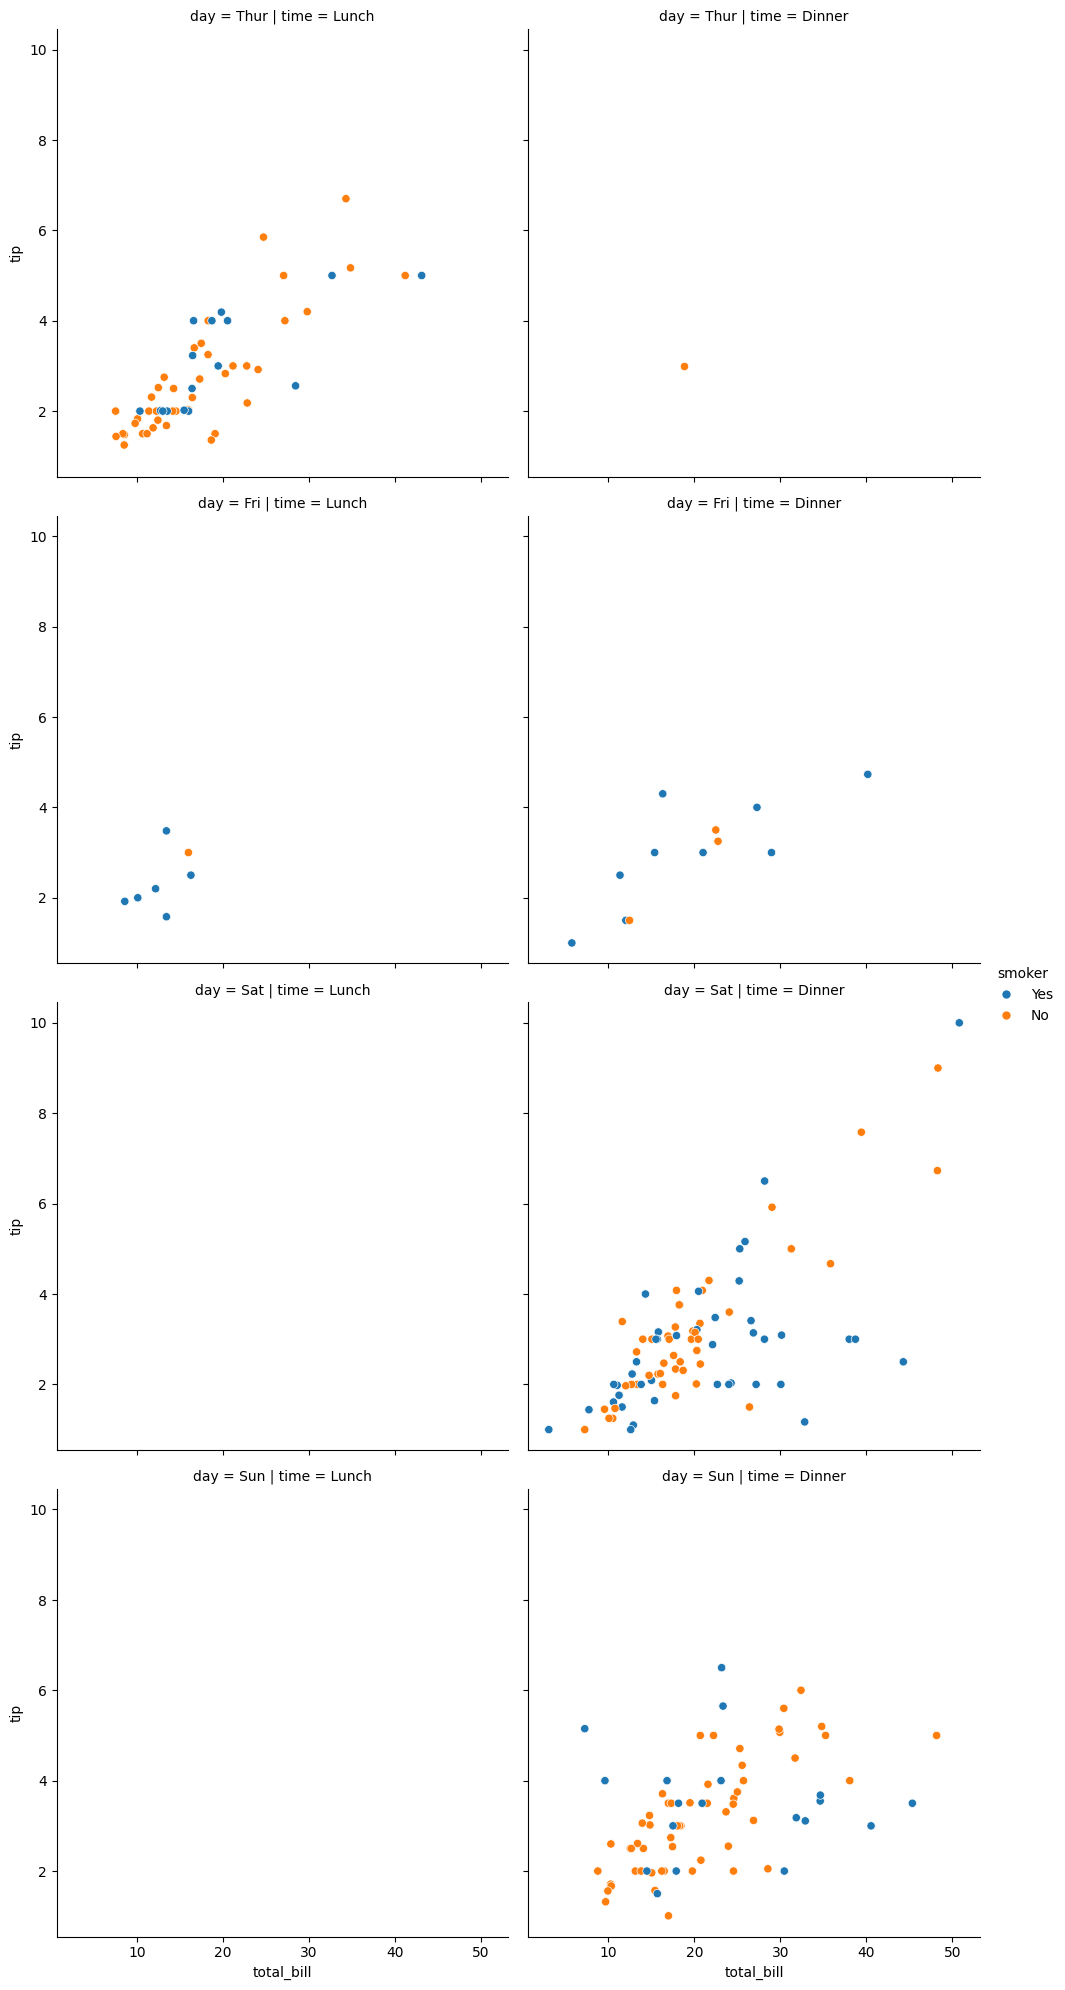

In [ ]:
sns.relplot(data=tips, x="total_bill",
            y="tip", col="time", row="day",
            hue="smoker")
plt.show()

---
### **2. Distribution plots**
Shows distribution of a variable including a KDE

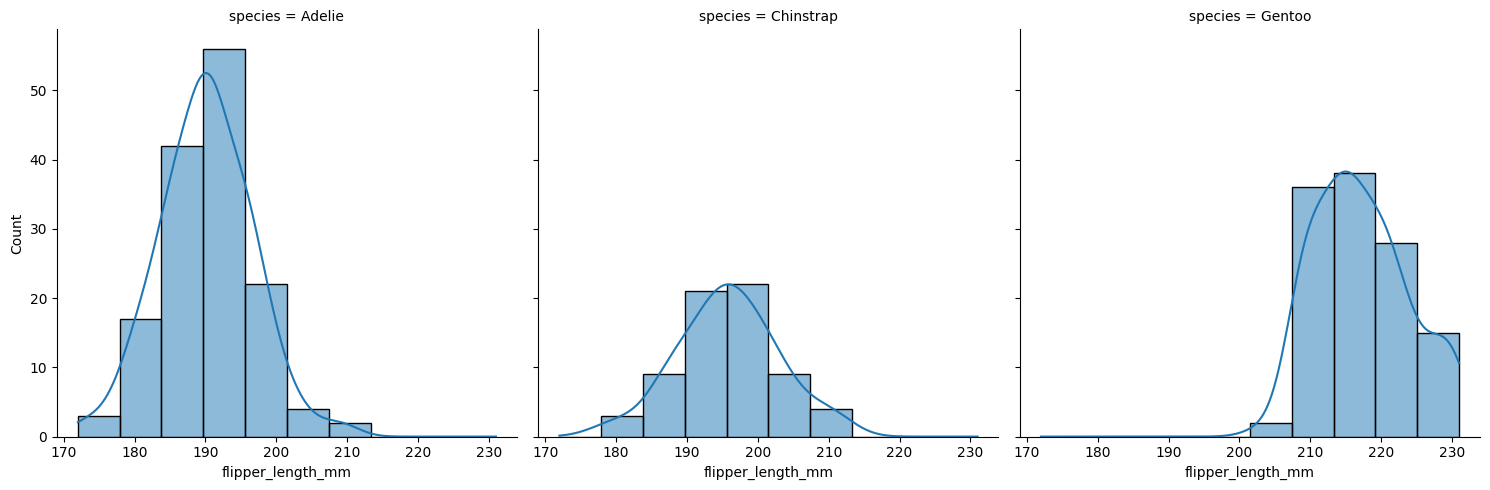

In [ ]:
#dist plot
sns.displot(data=penguins, x="flipper_length_mm",
            col="species", kde=True)
plt.show()

---
### **3. Categorical plots**
Compare a number across categories: bar, count, box, violin, swarm, boxen, point

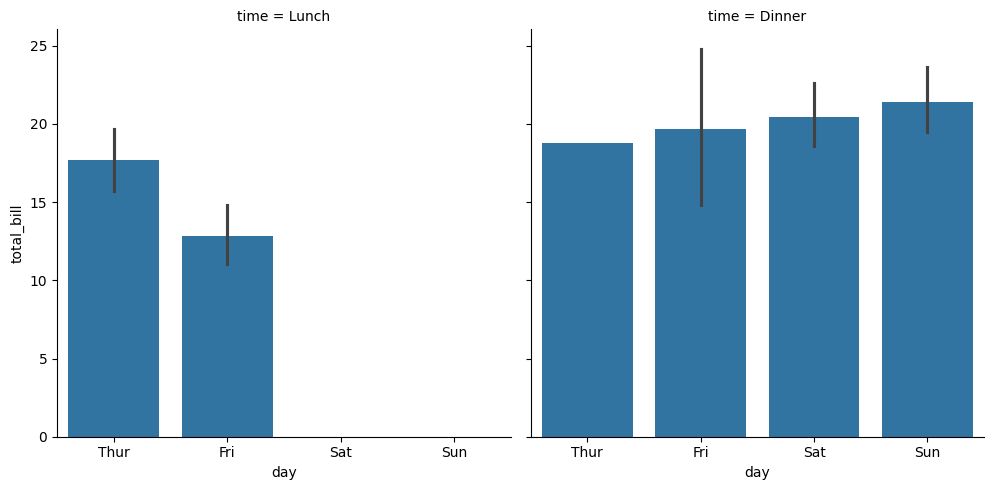

In [ ]:
#catplot: comparison between categories
sns.catplot(data=tips, x="day", y="total_bill",
            col="time", kind="box")
plt.show()

---
### **4. Regression plots**

Adds a fitted regression line.

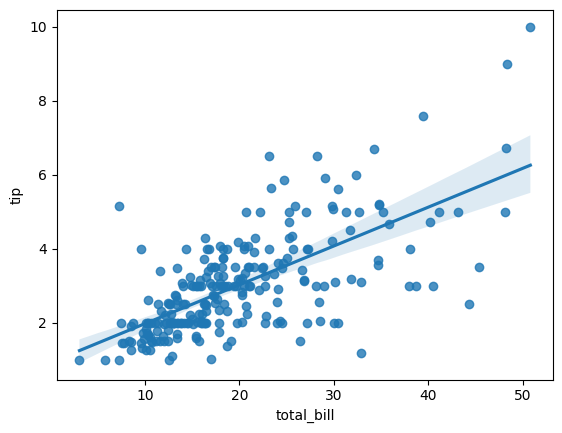

In [ ]:
#regplot
sns.regplot(data=tips, x="total_bill", y="tip")
plt.show()

### **Exercise**

Use `tips`, `penguins` and `flights` datasets.

1. **Scatter** penguins `bill_length_mm` vs `bill_depth_mm`, coloured by `species`.
2. **Stacked histogram** of `total_bill` split by `time`.
3. **Boxplot** of penguin `body_mass_g` by `species`, with `sex` as `hue`.
4. **Bar chart** of the average `tip` per `day`.
5. **Correlation heatmap** of the numeric penguin columns. (skip)
6. **Subplots:** put all 4 charts in one figure.

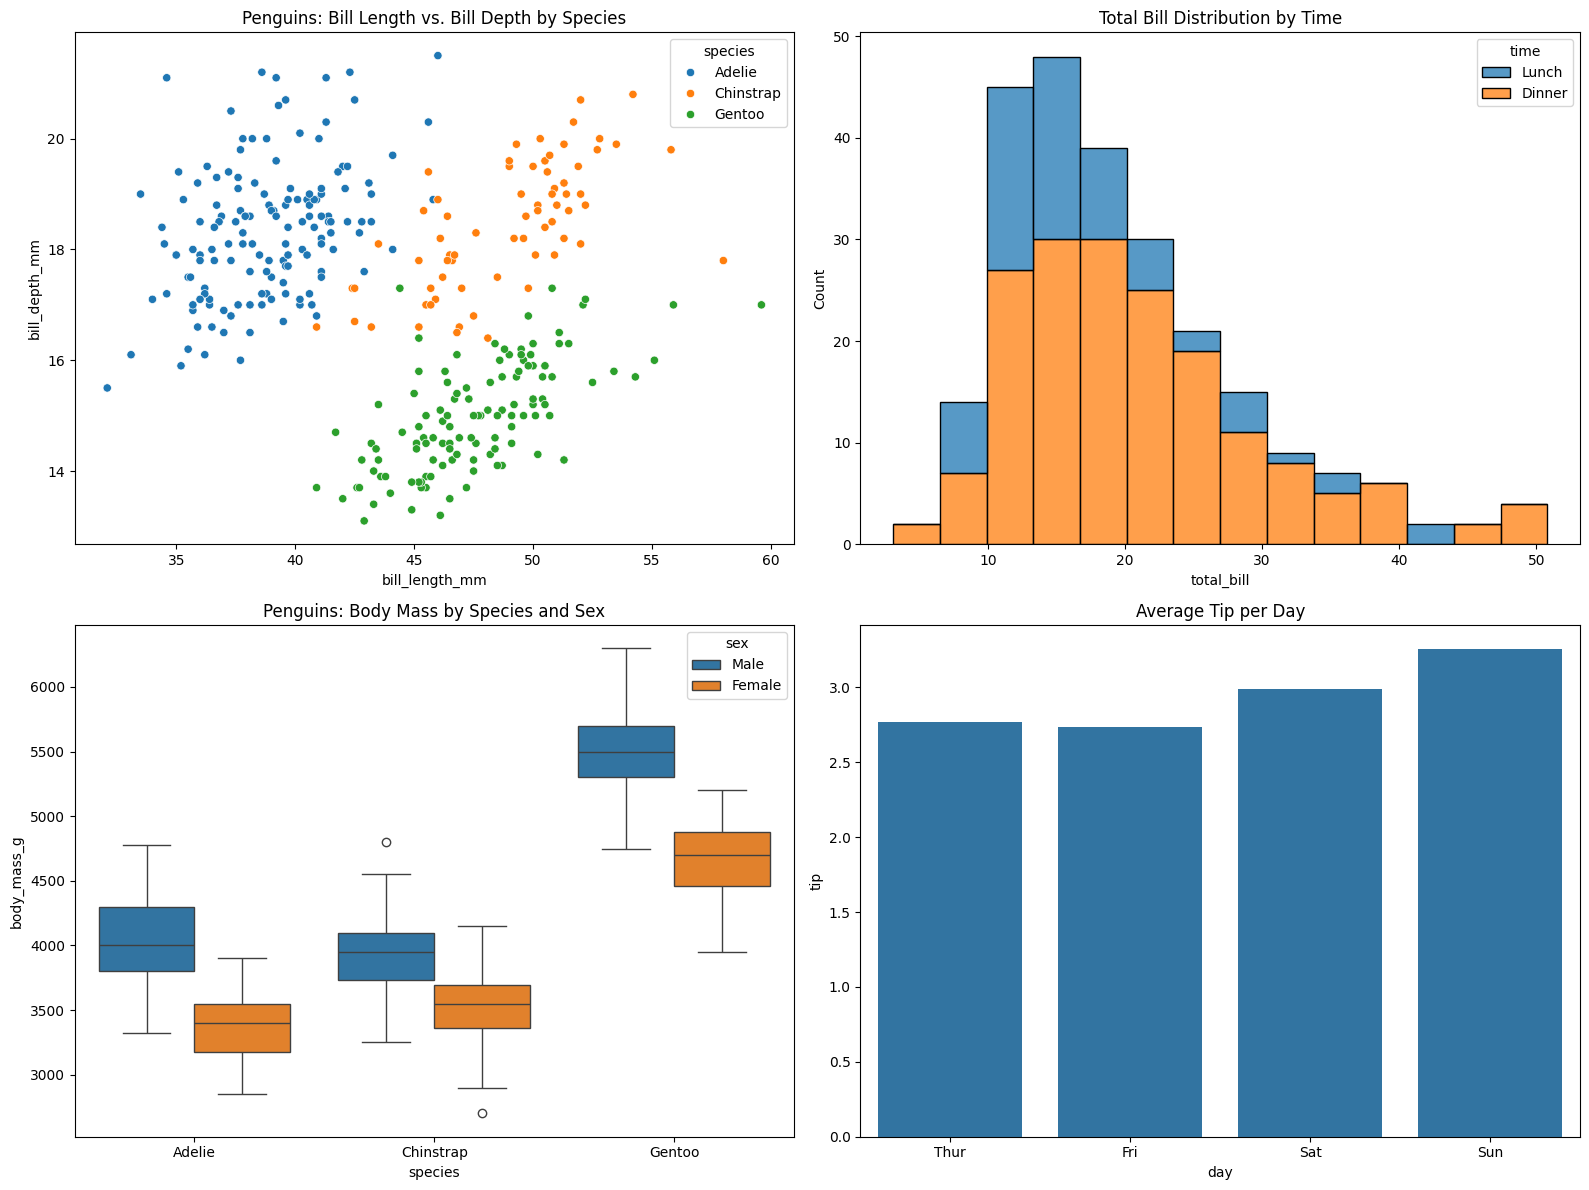

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter penguins bill_length_mm vs bill_depth_mm, coloured by species.
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", ax=axes[0, 0])
axes[0, 0].set_title("Penguins: Bill Length vs. Bill Depth by Species")

# 2. Stacked histogram of total_bill split by time.
sns.histplot(data=tips, x="total_bill", hue="time", multiple="stack", ax=axes[0, 1])
axes[0, 1].set_title("Total Bill Distribution by Time")

# 3. Boxplot of penguin body_mass_g by species, with sex as hue.
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="sex", ax=axes[1, 0])
axes[1, 0].set_title("Penguins: Body Mass by Species and Sex")

# 4. Bar chart of the average tip per day.
sns.barplot(data=tips, x="day", y="tip", errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title("Average Tip per Day")

plt.tight_layout()
plt.show()

##Group 4 work
data set to be flights

1.Line plot of passengers by month (averaged across years) to show seasonality.

2.Heatmap of passengers with axes year × month.

3.Distributions of monthly passengers across all years.

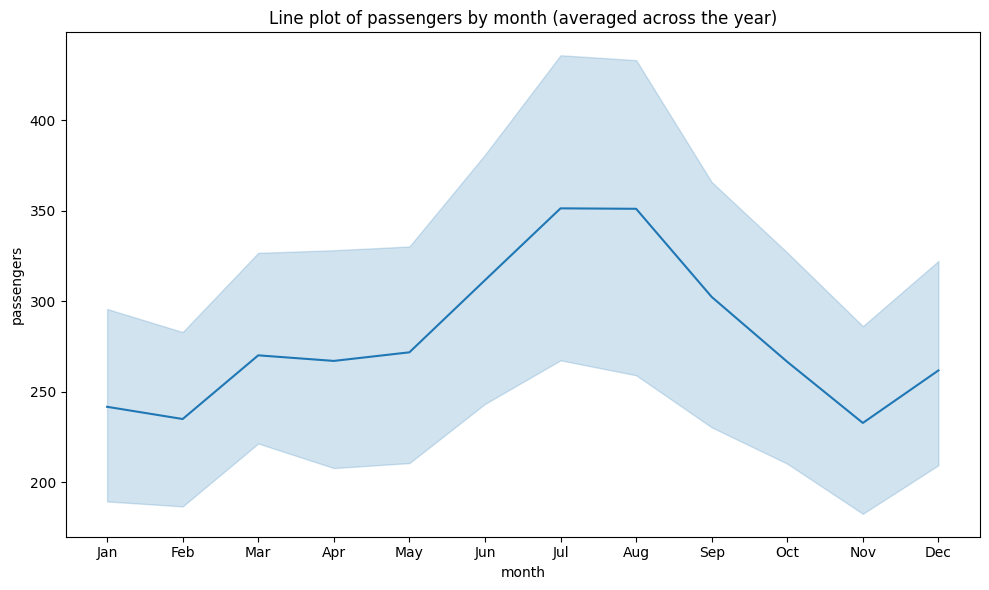

In [6]:
import matplotlib.pyplot as plt

# Create a new figure and axes for this plot
fig, ax = plt.subplots(figsize=(10, 6))

# lineplot of passengers by month (averaged across years) to show seasonality
sns.lineplot(data=flights, x="month", y="passengers", ax=ax)
ax.set_title("Line plot of passengers by month (averaged across the year)")
plt.tight_layout()
plt.show()


This line plot displays the average number of passengers for each month, aggregated across all years present in the flights dataset. You can observe the seasonality in air travel: passenger numbers are generally lower in the early months of the year, start to rise around spring, peak in the summer months (July and August), and then gradually decline towards the end of the year, with a slight bump in December. The shaded area around the line represents the confidence interval, indicating the variability or spread of passenger numbers around the average for each month.

---

/tmp/ipykernel_4268/1185098857.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights_pivot = flights.pivot_table(index='year', columns='month', values='passengers')


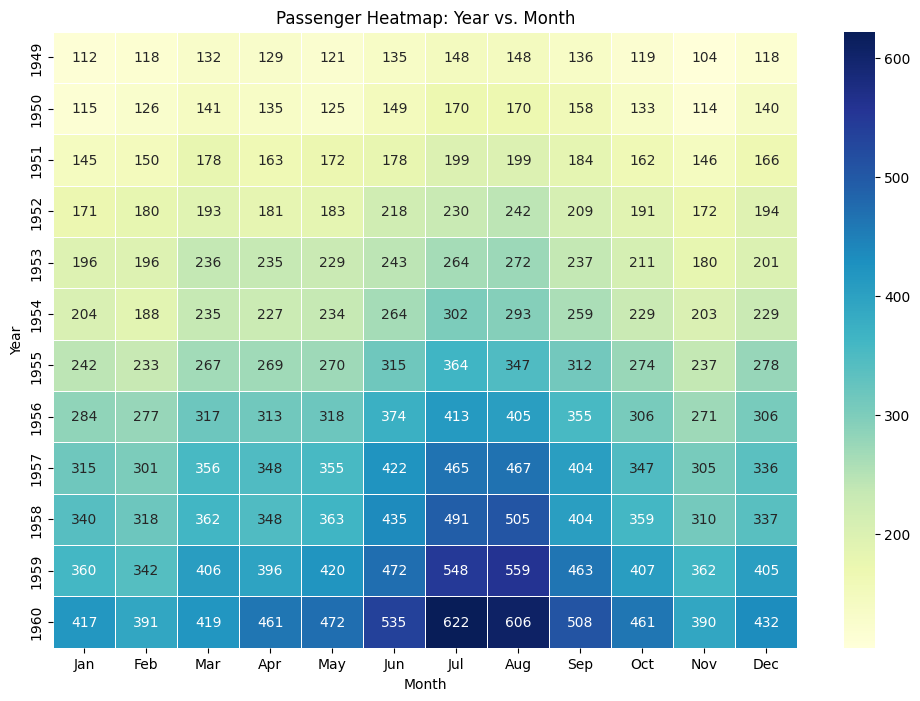

In [9]:
# Reshape the flights data for the heatmap
flights_pivot = flights.pivot_table(index='year', columns='month', values='passengers')
plt.figure(figsize=(12, 8))
sns.heatmap(flights_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Passenger Heatmap: Year vs. Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

I will create a heatmap of passengers by year and month. First, I will reshape the data using pivot_table to have years as rows, months as columns, and passenger counts as values. Then, I will use seaborn.heatmap to visualize this data, which will clearly show how passenger numbers vary across months and years.

You're seeing a ValueError because the fmt="d" you're using in the heatmap is for integers, but the data in flights_pivot is in a float format. To resolve this, I'll update the fmt parameter to fmt=".0f", which will display the passenger numbers as whole numbers without decimal places in the heatmap.

The heatmap of passengers by year and month has been successfully generated. This visualization clearly shows the seasonal patterns of air travel across different years, with brighter colors indicating higher passenger numbers. You can observe a consistent increase in passenger numbers over the years, as well as the peak travel months (typically July and August) and off-peak months (e.g., November, February) within each year.

This heatmap visualizes the number of airline passengers (passengers) for each combination of year (rows) and month (columns). The color intensity directly corresponds to the passenger count, with darker shades of blue indicating a higher number of passengers and lighter shades indicating fewer passengers. You can clearly see a few trends:

Overall Growth: As you move down the rows (from 1949 to 1960), the colors generally become darker, indicating a consistent increase in total passenger numbers over the years.
Seasonality: Within each year (across the columns), there's a strong seasonal pattern. Passenger numbers are typically lower in the early months (January, February), gradually increase through spring, peak significantly in the summer months (July, August), and then decline towards the end of the year, with a slight resurgence in December.
Specific Peaks/Troughs: For example, July and August consistently show the highest passenger numbers each year, while November and February often show the lowest. This pattern is very evident across all years displayed.

---

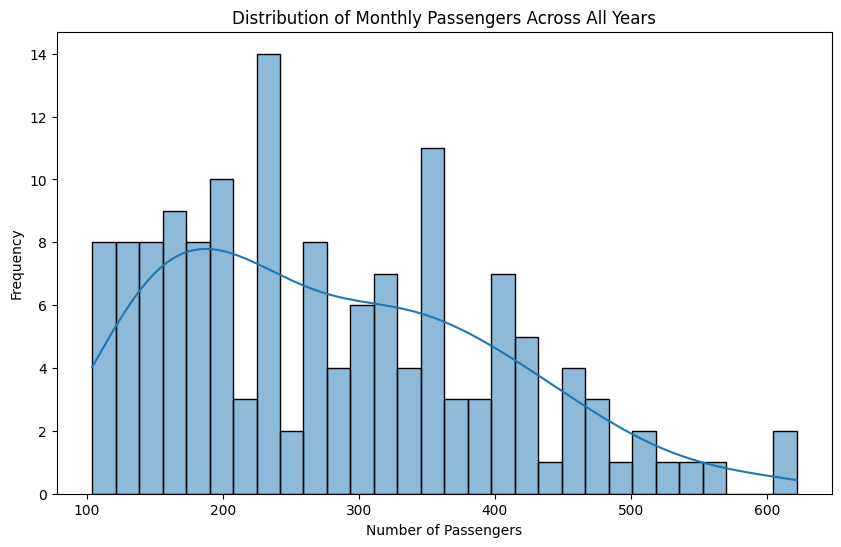

In [10]:
# Distributions of monthly passengers across all years
plt.figure(figsize=(10, 6))
sns.histplot(data=flights, x="passengers", bins=30, kde=True)
plt.title('Distribution of Monthly Passengers Across All Years')
plt.xlabel('Number of Passengers')
plt.ylabel('Frequency')
plt.show()

The distribution plot, which is a histogram with an overlaid Kernel Density Estimate (KDE), shows the frequency of different monthly passenger counts.

Histogram Bars: Each bar represents a range of passenger numbers, and its height indicates how many months fall within that range across all the years in the dataset. You can see that lower passenger counts (e.g., around 150-250) occur more frequently, while very high passenger counts (e.g., above 500) are less common.
KDE Curve: The blue curve is a smoothed estimate of the probability density function. It helps to visualize the overall shape of the distribution, making it easier to see where passenger numbers are most concentrated and how they spread out. In this case, it confirms the right-skewed nature of the data, meaning there's a longer tail towards higher passenger numbers, though the bulk of the data lies on the lower end of the spectrum.